In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/atscc_checkpoints_v10_reg/training_history.csv")

In [2]:
df.head() 

,epoch,train_loss,val_loss,alignment,uniformity,lr
0,1,1.563708,1.288612,0.303713,-2.852057,0.000002
1,2,1.078618,1.078028,0.301305,-3.016517,0.000003
2,3,0.869532,0.941752,0.277638,-3.130637,0.000005
3,4,0.738074,0.850456,0.268834,-3.173000,0.000007
4,5,0.647032,0.780074,0.256245,-3.224920,0.000007


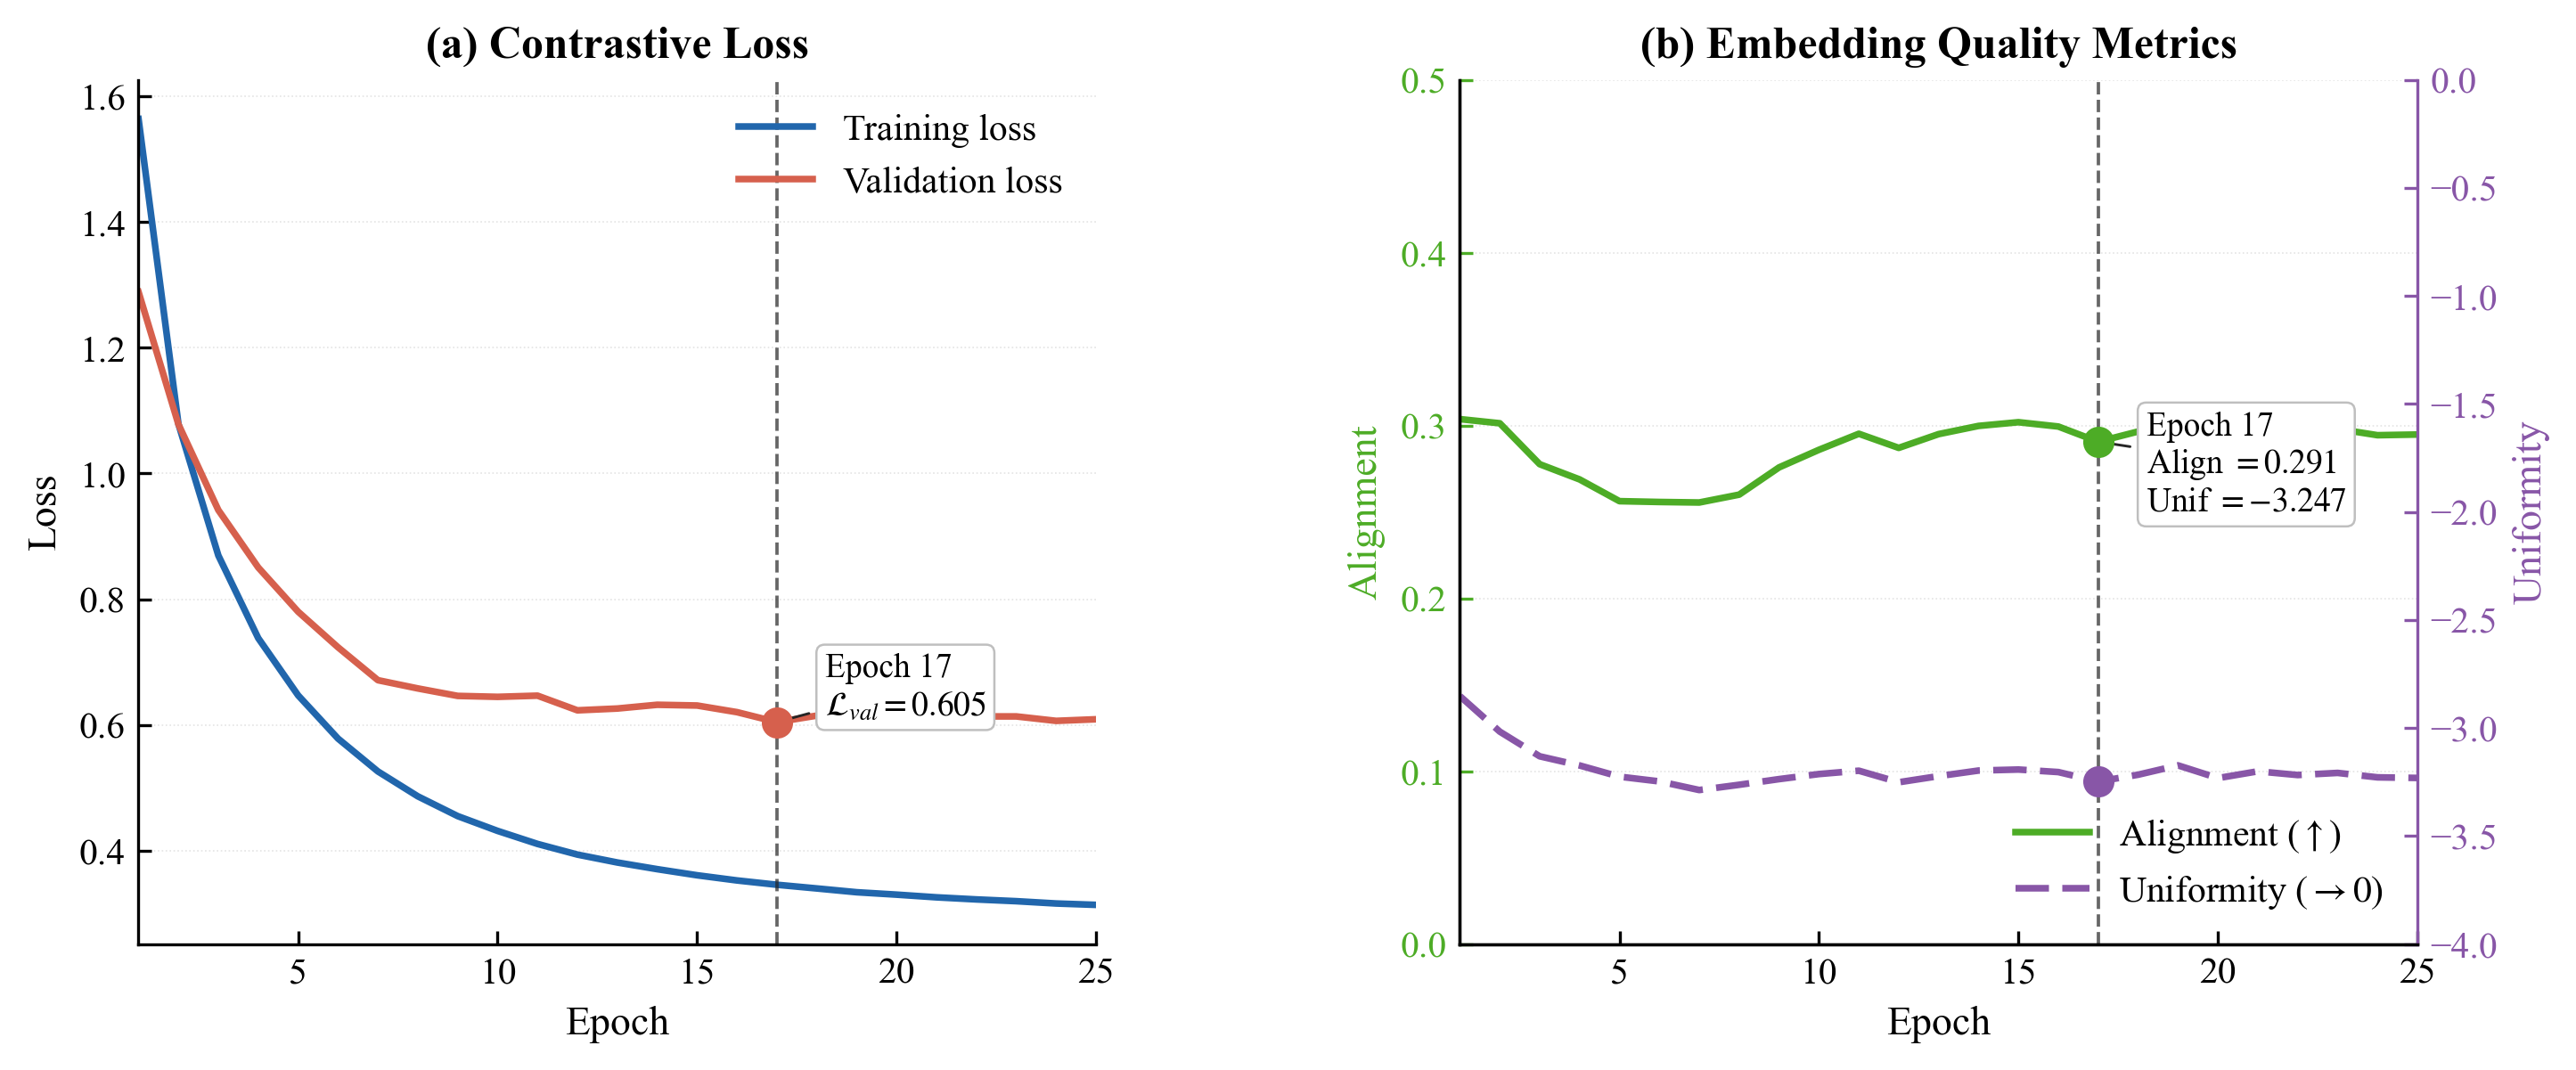

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import rcParams
import numpy as np

# ── Akademik stil ayarları ───────────────────────────────────────────────────
rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":   "stix",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "axes.labelsize":     11,
    "axes.titlesize":     12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "figure.dpi":         300,
})

# ── Renk paleti (colorblind-friendly, akademik) ──────────────────────────────
C_TRAIN   = "#2166AC"   # mavi    – train loss
C_VAL     = "#D6604D"   # kırmızı – val loss
C_ALIGN   = "#4DAC26"   # yeşil   – alignment
C_UNIF    = "#8856A7"   # mor     – uniformity
C_BEST    = "#252525"   # siyah   – best epoch çizgisi

# ── Veri ────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/"
    "atscc_checkpoints_v10_reg/training_history.csv"
)

BEST = 17
best_val   = df.loc[df["epoch"] == BEST, "val_loss"].values[0]
best_align = df.loc[df["epoch"] == BEST, "alignment"].values[0]
best_unif  = df.loc[df["epoch"] == BEST, "uniformity"].values[0]

# ── Şekil ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(11, 4.2),          # poster sütununa sığacak genişlik
    gridspec_kw={"wspace": 0.38}
)

# ════════════════════════════════════════════════════════════════════════════
# SOL: Contrastive Loss
# ════════════════════════════════════════════════════════════════════════════
ax1.plot(df["epoch"], df["train_loss"],
         color=C_TRAIN, linewidth=1.8, label="Training loss")
ax1.plot(df["epoch"], df["val_loss"],
         color=C_VAL,   linewidth=1.8, label="Validation loss")

# Best epoch — ince dikey çizgi + nokta
ax1.axvline(BEST, color=C_BEST, linestyle="--", linewidth=0.9, alpha=0.7)
ax1.scatter(BEST, best_val, color=C_VAL, s=55, zorder=5, clip_on=False)

# Annotation kutusu
ax1.annotate(
    f"Epoch {BEST}\n$\\mathcal{{L}}_{{val}}={best_val:.3f}$",
    xy=(BEST, best_val),
    xytext=(BEST + 1.2, best_val + 0.012),
    fontsize=9,
    arrowprops=dict(arrowstyle="-", color=C_BEST, lw=0.7),
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.75", lw=0.6),
)

ax1.set_title("(a) Contrastive Loss", fontweight="bold", pad=6)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xlim(1, 25)
ax1.grid(axis="y", linewidth=0.4, alpha=0.35, linestyle=":")
ax1.legend(loc="upper right")

# ════════════════════════════════════════════════════════════════════════════
# SAĞ: Embedding Quality  (iki y ekseni)
# ════════════════════════════════════════════════════════════════════════════
ax3 = ax2.twinx()

l1, = ax2.plot(df["epoch"], df["alignment"],
               color=C_ALIGN, linewidth=1.8, label="Alignment ($\\uparrow$)")
l2, = ax3.plot(df["epoch"], df["uniformity"],
               color=C_UNIF,  linewidth=1.8, linestyle=(0,(5,2)),
               label="Uniformity ($\\rightarrow 0$)")

# Best epoch
ax2.axvline(BEST, color=C_BEST, linestyle="--", linewidth=0.9, alpha=0.7)
ax2.scatter(BEST, best_align, color=C_ALIGN, s=55, zorder=5)
ax3.scatter(BEST, best_unif,  color=C_UNIF,  s=55, zorder=5)

# Annotation
ax2.annotate(
    f"Epoch {BEST}\nAlign $={best_align:.3f}$\nUnif $={best_unif:.3f}$",
    xy=(BEST, best_align),
    xytext=(BEST + 1.2, best_align - 0.04),
    fontsize=9,
    arrowprops=dict(arrowstyle="-", color=C_BEST, lw=0.7),
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.75", lw=0.6),
)

ax2.set_title("(b) Embedding Quality Metrics", fontweight="bold", pad=6)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Alignment", color=C_ALIGN)
ax3.set_ylabel("Uniformity", color=C_UNIF)
ax2.tick_params(axis="y", colors=C_ALIGN)
ax3.tick_params(axis="y", colors=C_UNIF)
ax3.spines["right"].set_visible(True)
ax3.spines["right"].set_linewidth(0.8)
ax3.spines["right"].set_color(C_UNIF)
ax2.set_xlim(1, 25)
ax2.set_ylim(0,   0.5)
ax3.set_ylim(-4,  0)
ax2.grid(axis="y", linewidth=0.4, alpha=0.35, linestyle=":")

# Birleşik legend
ax2.legend(handles=[l1, l2], loc="lower right")

# ── Kaydet ───────────────────────────────────────────────────────────────────
fig.savefig(
    "atscc_training_poster.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
fig.savefig(
    "atscc_training_poster.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

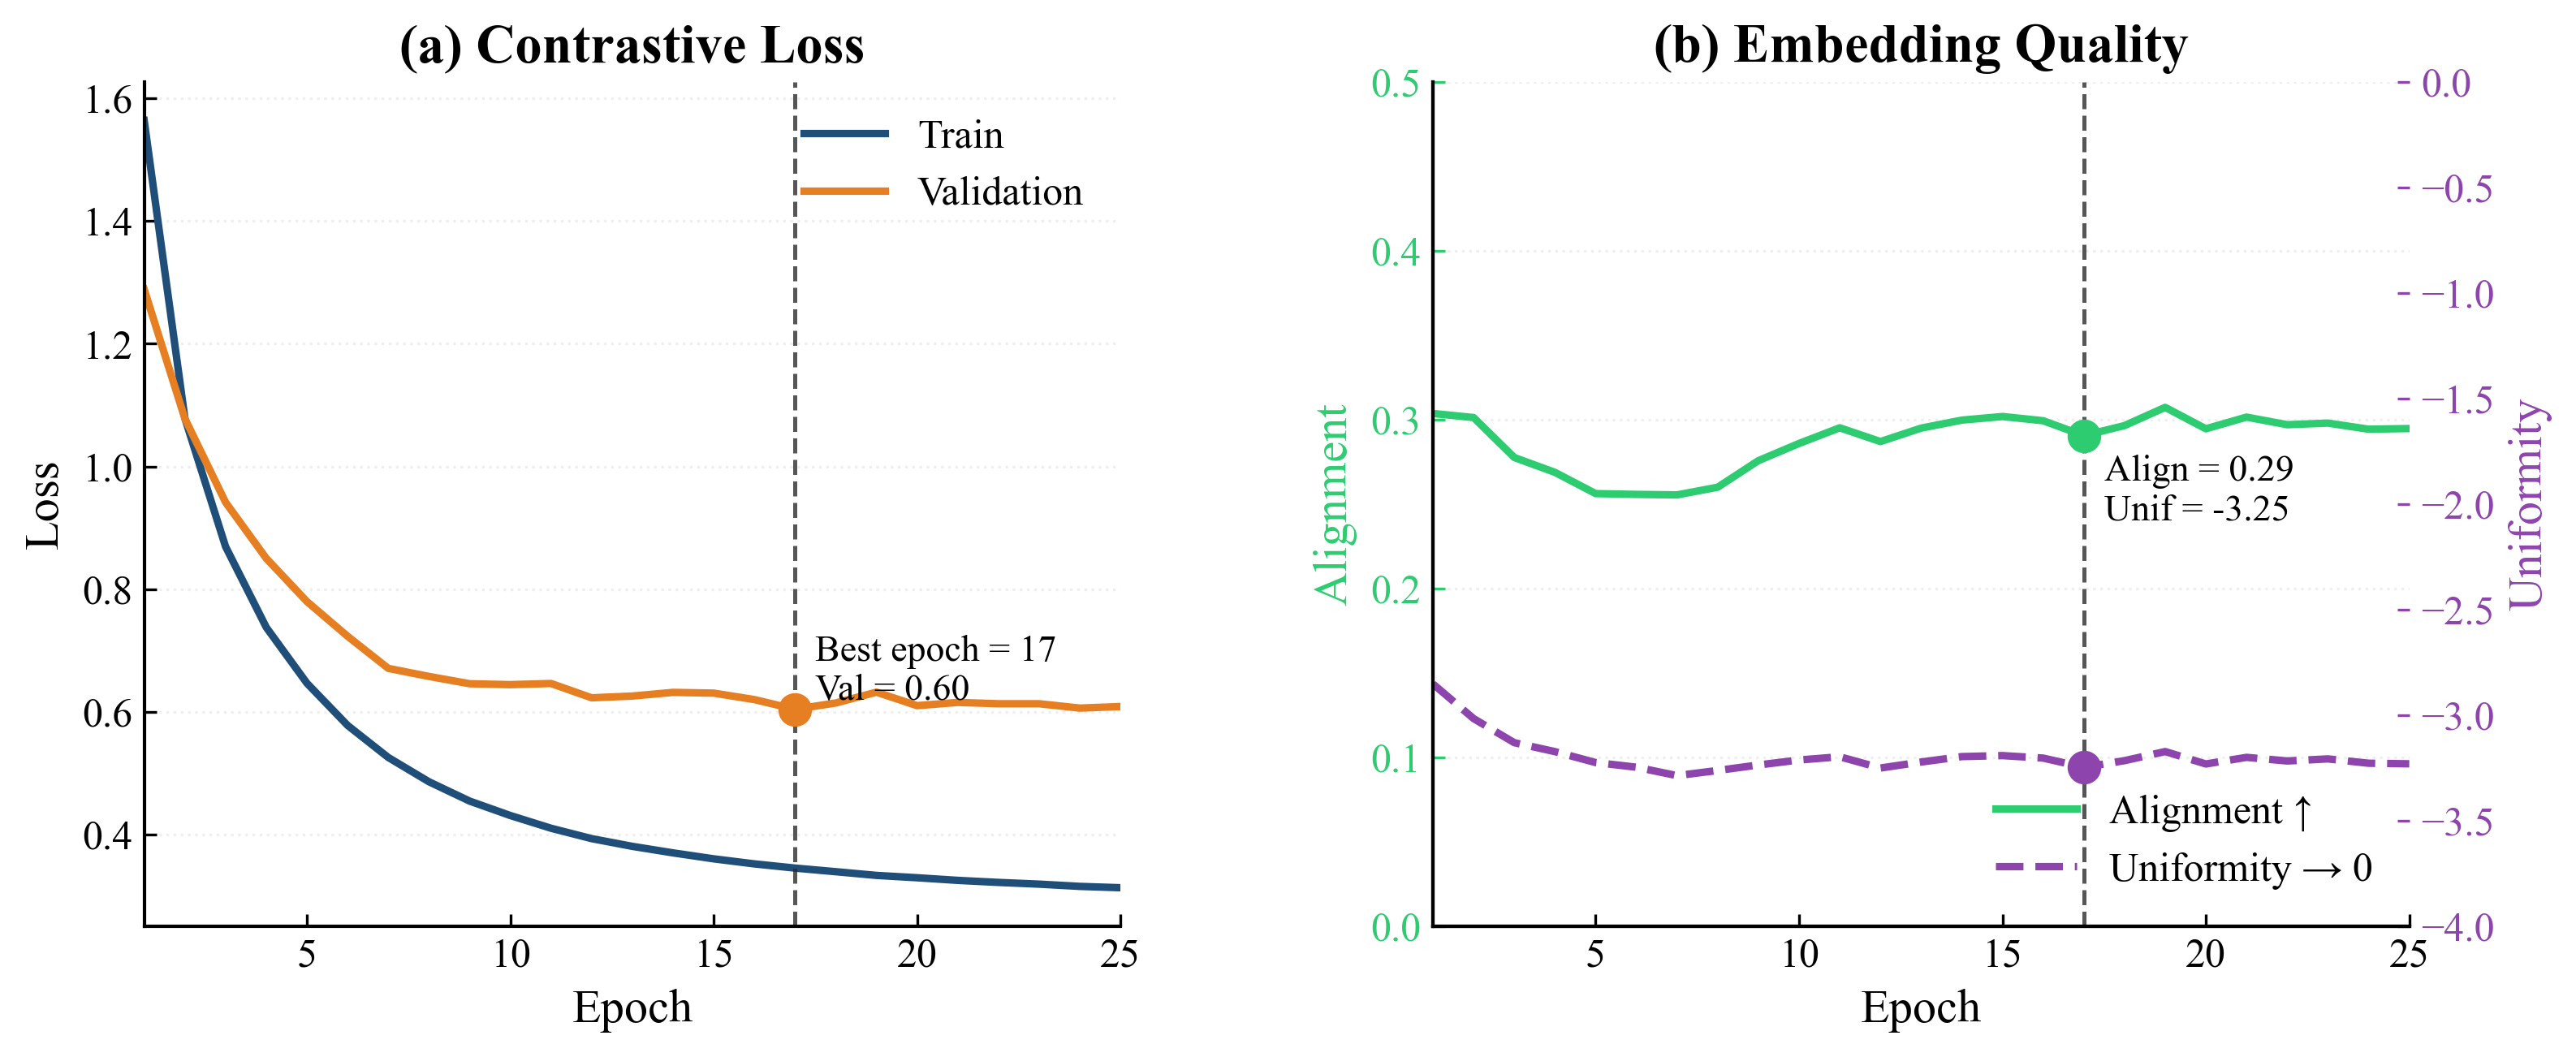

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── Poster için fontları büyüt ──────────────────────────────────────────────
rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":   "stix",

    # 🔥 Poster scale
    "axes.titlesize":     16,
    "axes.labelsize":     14,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    12,

    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     1.0,

    "xtick.direction":    "in",
    "ytick.direction":    "in",

    "figure.dpi":         300,
})

# ── Renkler (biraz daha poster-friendly) ────────────────────────────────────
C_TRAIN = "#1f4e79"   # koyu mavi
C_VAL   = "#e67e22"   # turuncu (kırmızı yerine daha okunaklı)
C_ALIGN = "#2ecc71"   # yeşil
C_UNIF  = "#8e44ad"   # mor
C_BEST  = "#2c2c2c"

# ── Veri ────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/"
    "atscc_checkpoints_v10_reg/training_history.csv"
)

BEST = 17
best_val   = df.loc[df["epoch"] == BEST, "val_loss"].values[0]
best_align = df.loc[df["epoch"] == BEST, "alignment"].values[0]
best_unif  = df.loc[df["epoch"] == BEST, "uniformity"].values[0]

# ── Figure (biraz daha geniş) ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={"wspace": 0.32}
)

# ════════════════════════════════════════════════════════════════════════════
# SOL: Contrastive Loss
# ════════════════════════════════════════════════════════════════════════════
ax1.plot(df["epoch"], df["train_loss"],
         color=C_TRAIN, linewidth=2.2, label="Train")

ax1.plot(df["epoch"], df["val_loss"],
         color=C_VAL, linewidth=2.2, label="Validation")

# Best epoch (daha belirgin)
ax1.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.2, alpha=0.8)
ax1.scatter(BEST, best_val, color=C_VAL, s=80, zorder=5)

# 🔥 Daha sade annotation
ax1.text(
    BEST + 0.5,
    best_val + 0.015,
    f"Best epoch = {BEST}\nVal = {best_val:.2f}",
    fontsize=11
)

ax1.set_title("(a) Contrastive Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xlim(1, 25)

# 🔥 Grid çok hafif
ax1.grid(axis="y", linestyle=":", alpha=0.2)

ax1.legend(loc="upper right")

# ════════════════════════════════════════════════════════════════════════════
# SAĞ: Embedding Quality
# ════════════════════════════════════════════════════════════════════════════
ax3 = ax2.twinx()

l1, = ax2.plot(df["epoch"], df["alignment"],
               color=C_ALIGN, linewidth=2.2,
               label="Alignment ↑")

l2, = ax3.plot(df["epoch"], df["uniformity"],
               color=C_UNIF, linewidth=2.2,
               linestyle="--",
               label="Uniformity → 0")

# Best epoch
ax2.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.2, alpha=0.8)
ax2.scatter(BEST, best_align, color=C_ALIGN, s=80, zorder=5)
ax3.scatter(BEST, best_unif, color=C_UNIF, s=80, zorder=5)

# 🔥 Daha temiz annotation
ax2.text(
    BEST + 0.5,
    best_align - 0.05,
    f"Align = {best_align:.2f}\nUnif = {best_unif:.2f}",
    fontsize=11
)

ax2.set_title("(b) Embedding Quality", fontweight="bold")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Alignment", color=C_ALIGN)
ax3.set_ylabel("Uniformity", color=C_UNIF)

ax2.tick_params(axis="y", colors=C_ALIGN)
ax3.tick_params(axis="y", colors=C_UNIF)

ax2.set_xlim(1, 25)
ax2.set_ylim(0, 0.5)
ax3.set_ylim(-4, 0)

# Grid sade
ax2.grid(axis="y", linestyle=":", alpha=0.2)

# Legend
ax2.legend(handles=[l1, l2], loc="lower right")

# ── Export ──────────────────────────────────────────────────────────────────
fig.savefig("atscc_training_poster.pdf", bbox_inches="tight")
fig.savefig("atscc_training_poster.png", bbox_inches="tight", dpi=300)

plt.show()

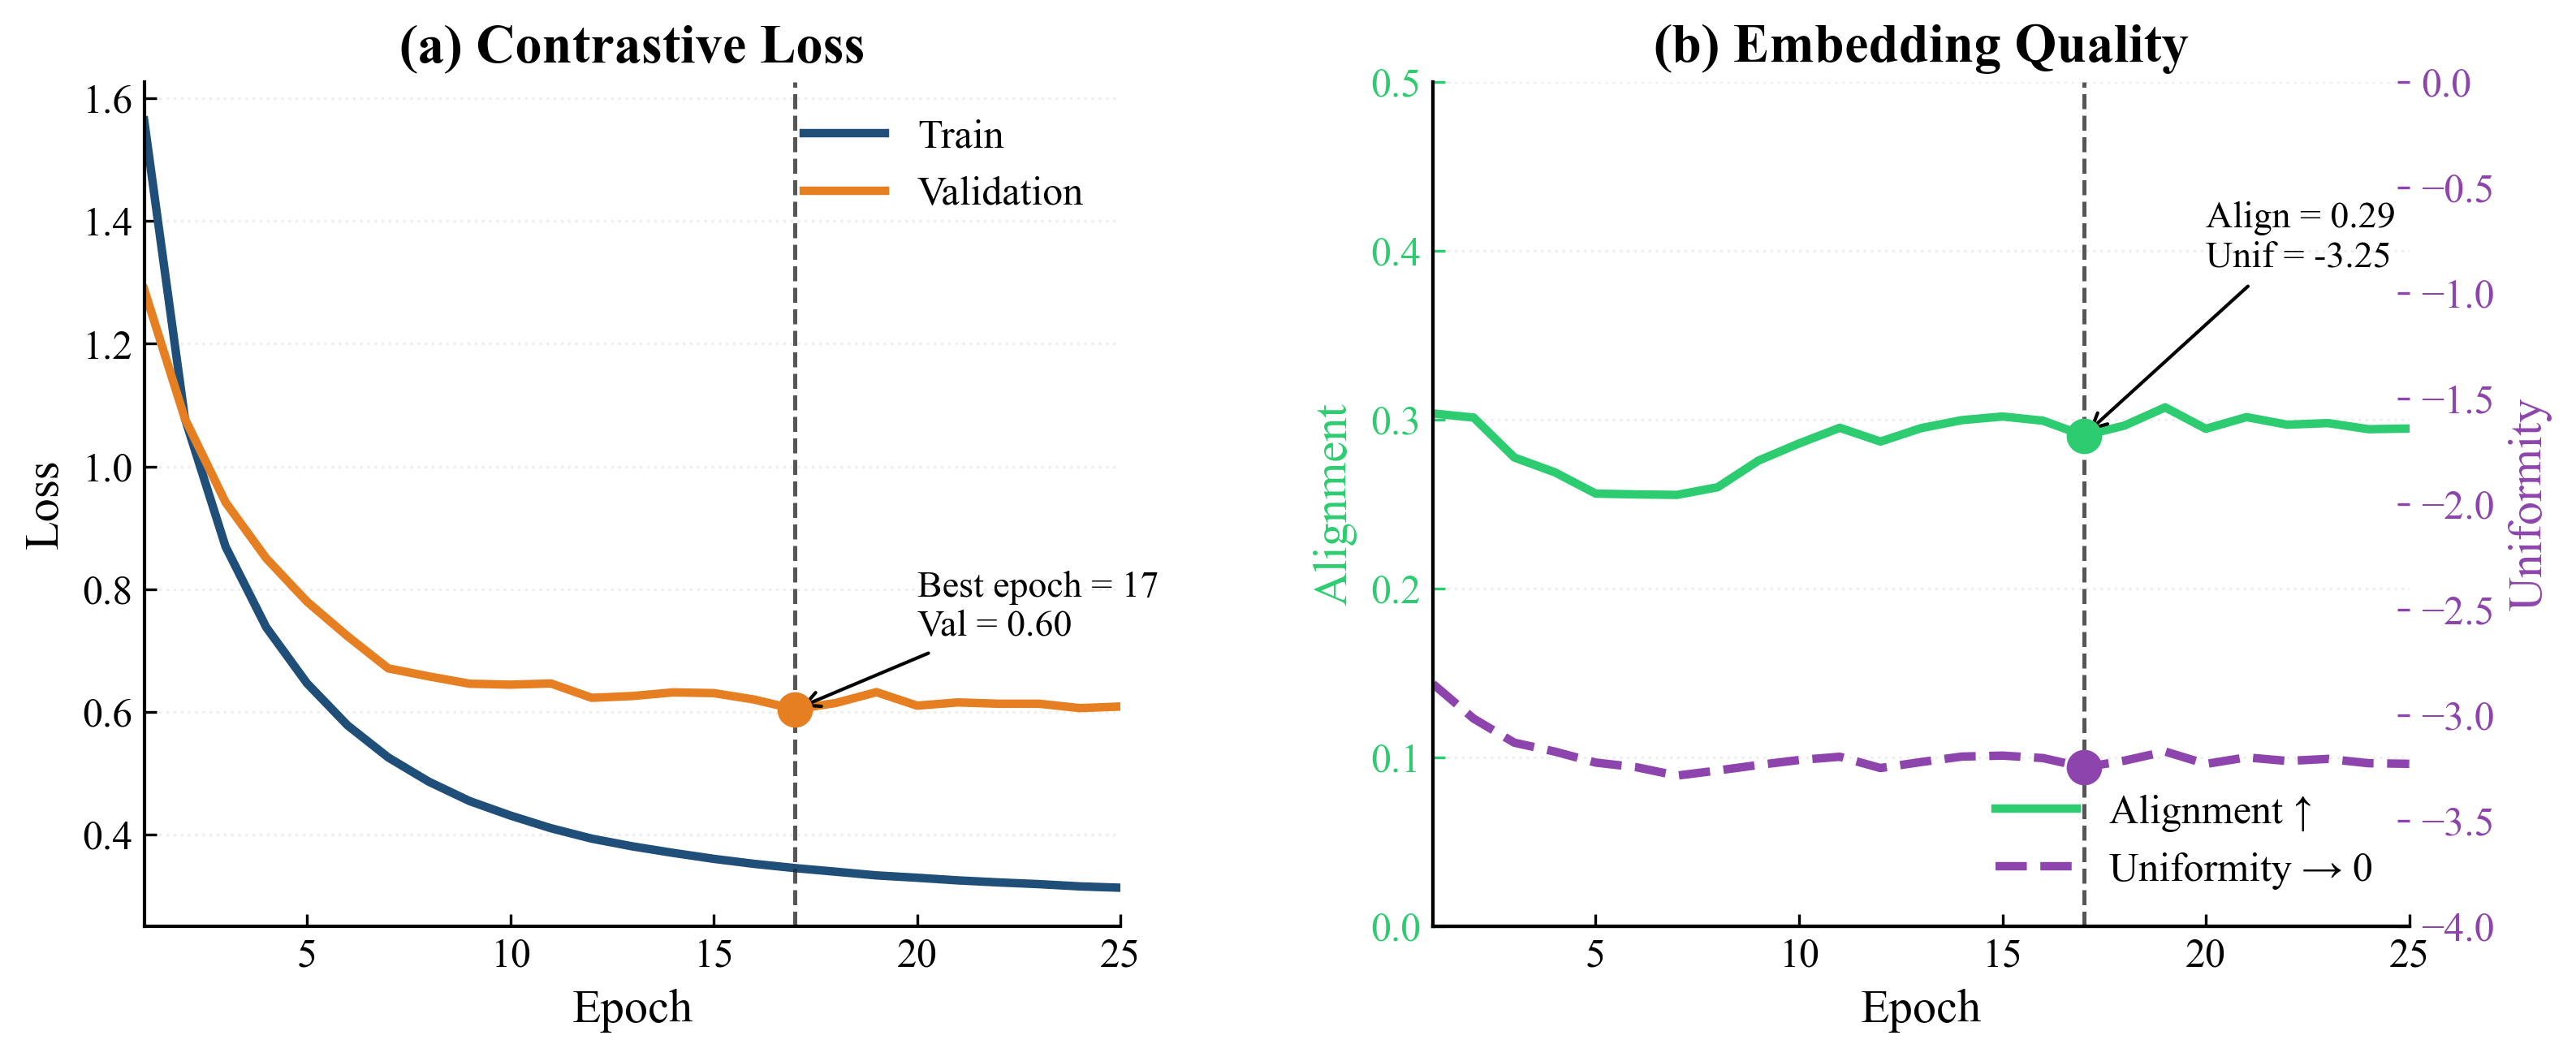

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── Poster stil ayarları ─────────────────────────────────────────────────────
rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":   "stix",

    "axes.titlesize":     16,
    "axes.labelsize":     14,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    12,

    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     1.0,

    "xtick.direction":    "in",
    "ytick.direction":    "in",

    "figure.dpi":         300,
})

# ── Renk paleti ──────────────────────────────────────────────────────────────
C_TRAIN = "#1f4e79"   # koyu mavi
C_VAL   = "#e67e22"   # turuncu
C_ALIGN = "#2ecc71"   # yeşil
C_UNIF  = "#8e44ad"   # mor
C_BEST  = "#2c2c2c"   # siyah

# ── Veri ────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/"
    "atscc_checkpoints_v10_reg/training_history.csv"
)

BEST = 17
best_val   = df.loc[df["epoch"] == BEST, "val_loss"].values[0]
best_align = df.loc[df["epoch"] == BEST, "alignment"].values[0]
best_unif  = df.loc[df["epoch"] == BEST, "uniformity"].values[0]

# ── Figure ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={"wspace": 0.32}
)

# ════════════════════════════════════════════════════════════════════════════
# (a) Contrastive Loss
# ════════════════════════════════════════════════════════════════════════════
ax1.plot(df["epoch"], df["train_loss"],
         color=C_TRAIN, linewidth=2.5, label="Train")

ax1.plot(df["epoch"], df["val_loss"],
         color=C_VAL, linewidth=2.5, label="Validation")

# Best epoch
ax1.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.2, alpha=0.8)
ax1.scatter(BEST, best_val, color=C_VAL, s=90, zorder=5)

# 🔥 DÜZELTİLMİŞ ANNOTATION (artık dışarıda)
ax1.annotate(
    f"Best epoch = {BEST}\nVal = {best_val:.2f}",
    xy=(BEST, best_val),
    xytext=(BEST + 3, best_val + 0.12),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=1),
)

ax1.set_title("(a) Contrastive Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xlim(1, 25)

ax1.grid(axis="y", linestyle=":", alpha=0.2)
ax1.legend(loc="upper right")

# ════════════════════════════════════════════════════════════════════════════
# (b) Embedding Quality
# ════════════════════════════════════════════════════════════════════════════
ax3 = ax2.twinx()

l1, = ax2.plot(df["epoch"], df["alignment"],
               color=C_ALIGN, linewidth=2.5,
               label="Alignment ↑")

l2, = ax3.plot(df["epoch"], df["uniformity"],
               color=C_UNIF, linewidth=2.5,
               linestyle="--",
               label="Uniformity → 0")

# Best epoch
ax2.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.2, alpha=0.8)
ax2.scatter(BEST, best_align, color=C_ALIGN, s=90, zorder=5)
ax3.scatter(BEST, best_unif, color=C_UNIF, s=90, zorder=5)

# 🔥 DÜZELTİLMİŞ ANNOTATION
ax2.annotate(
    f"Align = {best_align:.2f}\nUnif = {best_unif:.2f}",
    xy=(BEST, best_align),
    xytext=(BEST + 3, best_align + 0.10),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=1),
)

ax2.set_title("(b) Embedding Quality", fontweight="bold")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Alignment", color=C_ALIGN)
ax3.set_ylabel("Uniformity", color=C_UNIF)

ax2.tick_params(axis="y", colors=C_ALIGN)
ax3.tick_params(axis="y", colors=C_UNIF)

ax2.set_xlim(1, 25)
ax2.set_ylim(0, 0.5)
ax3.set_ylim(-4, 0)

ax2.grid(axis="y", linestyle=":", alpha=0.2)

# Legend
ax2.legend(handles=[l1, l2], loc="lower right")

# ── Export ──────────────────────────────────────────────────────────────────
fig.savefig("atscc_training_poster_FINAL.pdf", bbox_inches="tight")
fig.savefig("atscc_training_poster_FINAL.png", bbox_inches="tight", dpi=300)

plt.show()

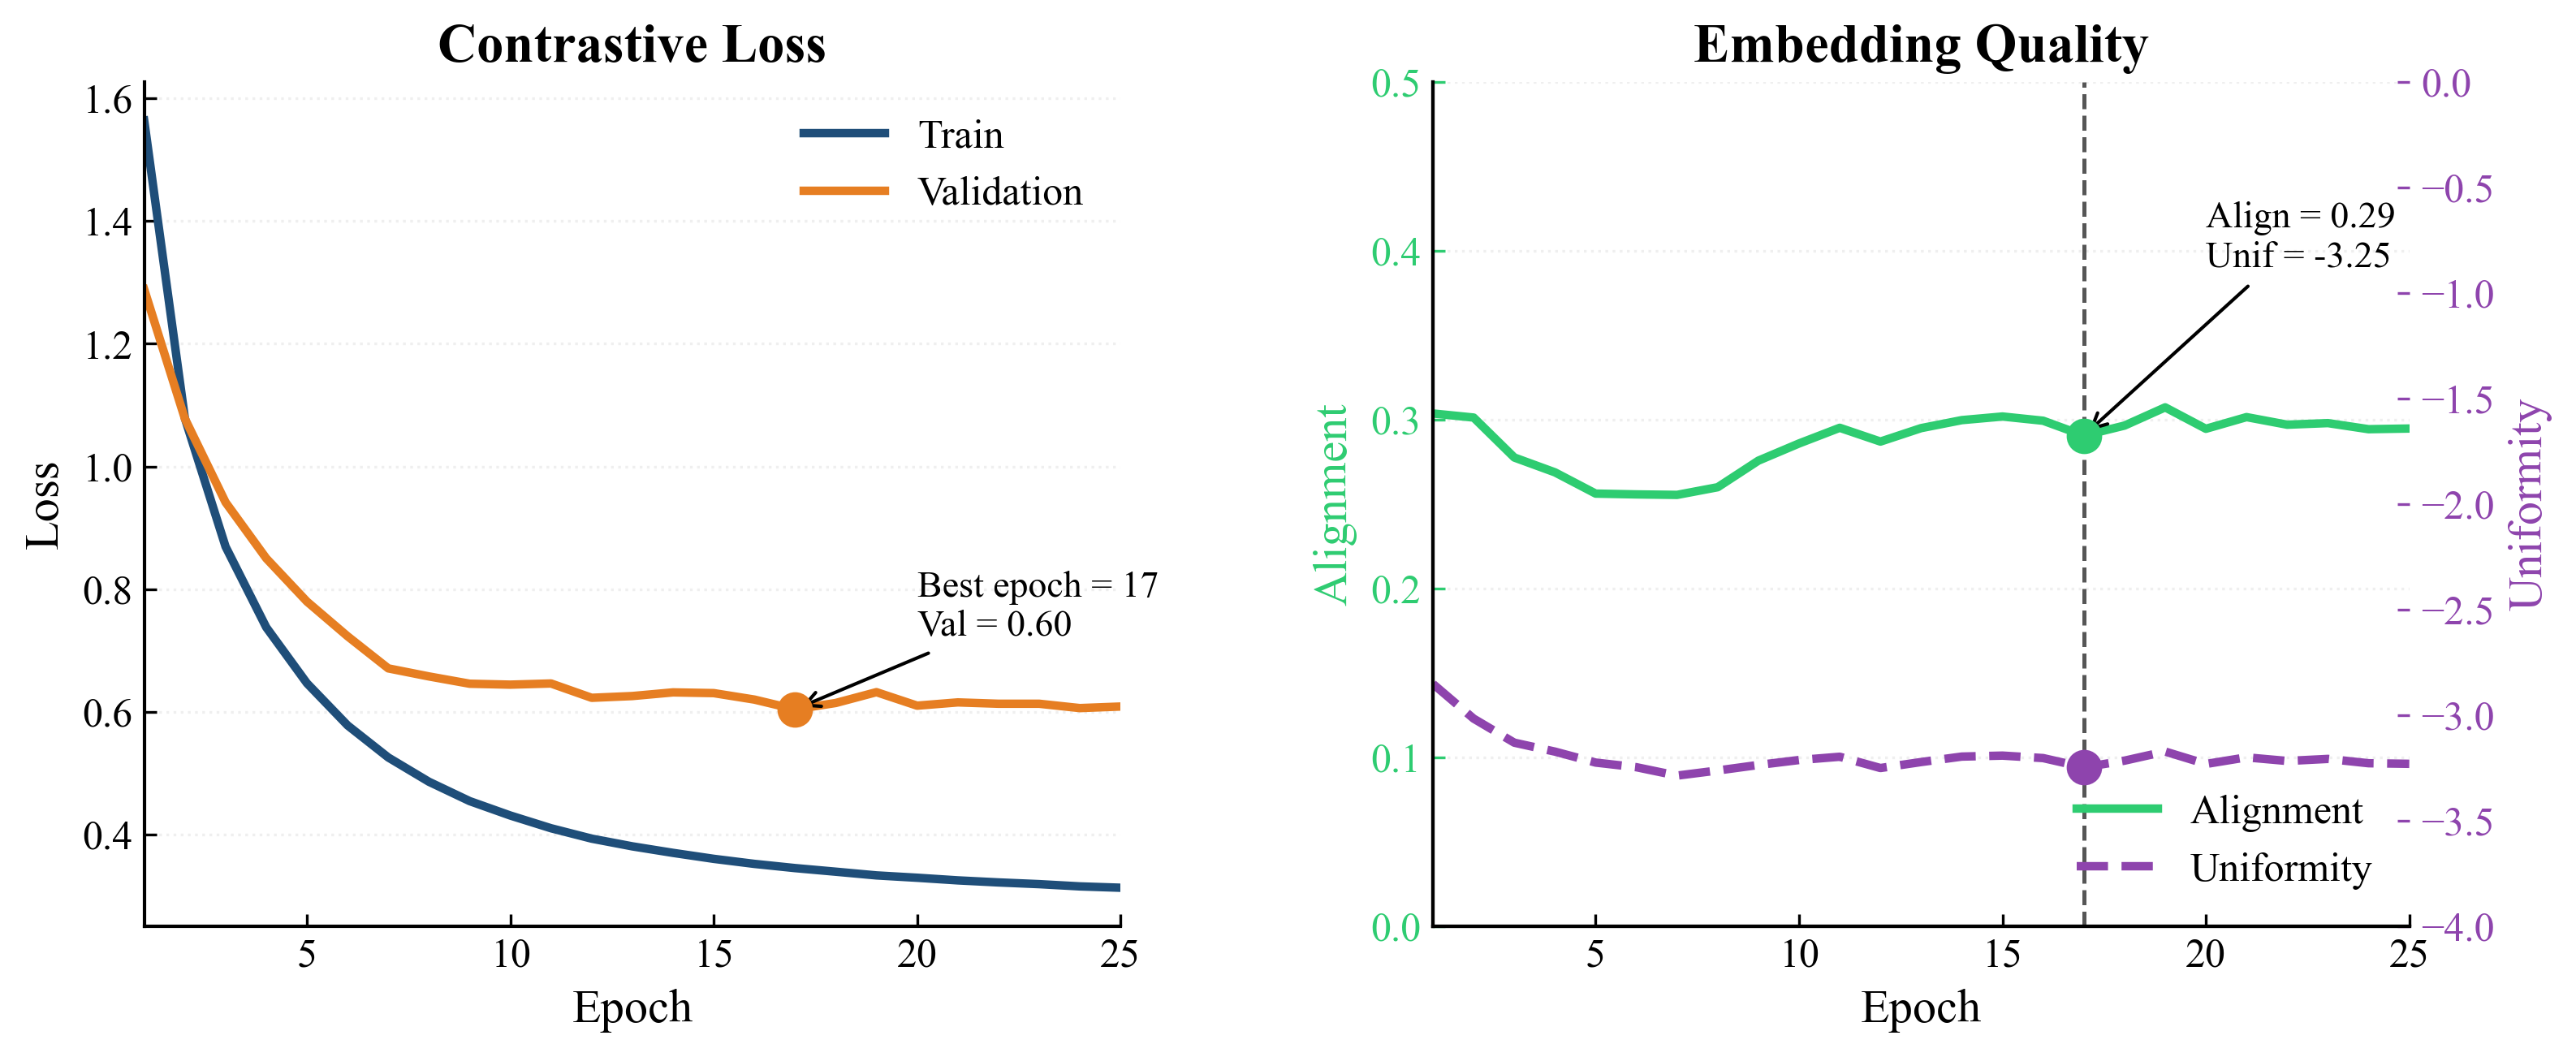

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── Poster stil ayarları ─────────────────────────────────────────────────────
rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":   "stix",

    "axes.titlesize":     16,
    "axes.labelsize":     14,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    12,

    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     1.0,

    "xtick.direction":    "in",
    "ytick.direction":    "in",

    "figure.dpi":         300,
})

# ── Renk paleti ──────────────────────────────────────────────────────────────
C_TRAIN = "#1f4e79"   # koyu mavi
C_VAL   = "#e67e22"   # turuncu
C_ALIGN = "#2ecc71"   # yeşil
C_UNIF  = "#8e44ad"   # mor
C_BEST  = "#2c2c2c"   # siyah

# ── Veri ────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/"
    "atscc_checkpoints_v10_reg/training_history.csv"
)

BEST = 17
best_val   = df.loc[df["epoch"] == BEST, "val_loss"].values[0]
best_align = df.loc[df["epoch"] == BEST, "alignment"].values[0]
best_unif  = df.loc[df["epoch"] == BEST, "uniformity"].values[0]

# ── Figure ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={"wspace": 0.32}
)

# ════════════════════════════════════════════════════════════════════════════
# (a) Contrastive Loss
# ════════════════════════════════════════════════════════════════════════════
ax1.plot(df["epoch"], df["train_loss"],
         color=C_TRAIN, linewidth=2.5, label="Train")

ax1.plot(df["epoch"], df["val_loss"],
         color=C_VAL, linewidth=2.5, label="Validation")

# Best epoch
ax1.scatter(BEST, best_val, color=C_VAL, s=90, zorder=5)

# 🔥 DÜZELTİLMİŞ ANNOTATION (artık dışarıda)
ax1.annotate(
    f"Best epoch = {BEST}\nVal = {best_val:.2f}",
    xy=(BEST, best_val),
    xytext=(BEST + 3, best_val + 0.12),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=1),
)

ax1.set_title("Contrastive Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xlim(1, 25)

ax1.grid(axis="y", linestyle=":", alpha=0.2)
ax1.legend(loc="upper right")

# ════════════════════════════════════════════════════════════════════════════
# (b) Embedding Quality
# ════════════════════════════════════════════════════════════════════════════
ax3 = ax2.twinx()

l1, = ax2.plot(df["epoch"], df["alignment"],
               color=C_ALIGN, linewidth=2.5,
               label="Alignment")

l2, = ax3.plot(df["epoch"], df["uniformity"],
               color=C_UNIF, linewidth=2.5,
               linestyle="--",
               label="Uniformity")

# Best epoch
ax2.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.2, alpha=0.8)
ax2.scatter(BEST, best_align, color=C_ALIGN, s=90, zorder=5)
ax3.scatter(BEST, best_unif, color=C_UNIF, s=90, zorder=5)

# 🔥 DÜZELTİLMİŞ ANNOTATION
ax2.annotate(
    f"Align = {best_align:.2f}\nUnif = {best_unif:.2f}",
    xy=(BEST, best_align),
    xytext=(BEST + 3, best_align + 0.10),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=1),
)

ax2.set_title("Embedding Quality", fontweight="bold")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Alignment", color=C_ALIGN)
ax3.set_ylabel("Uniformity", color=C_UNIF)

ax2.tick_params(axis="y", colors=C_ALIGN)
ax3.tick_params(axis="y", colors=C_UNIF)

ax2.set_xlim(1, 25)
ax2.set_ylim(0, 0.5)
ax3.set_ylim(-4, 0)

ax2.grid(axis="y", linestyle=":", alpha=0.2)

# Legend
ax2.legend(handles=[l1, l2], loc="lower right")


plt.show()

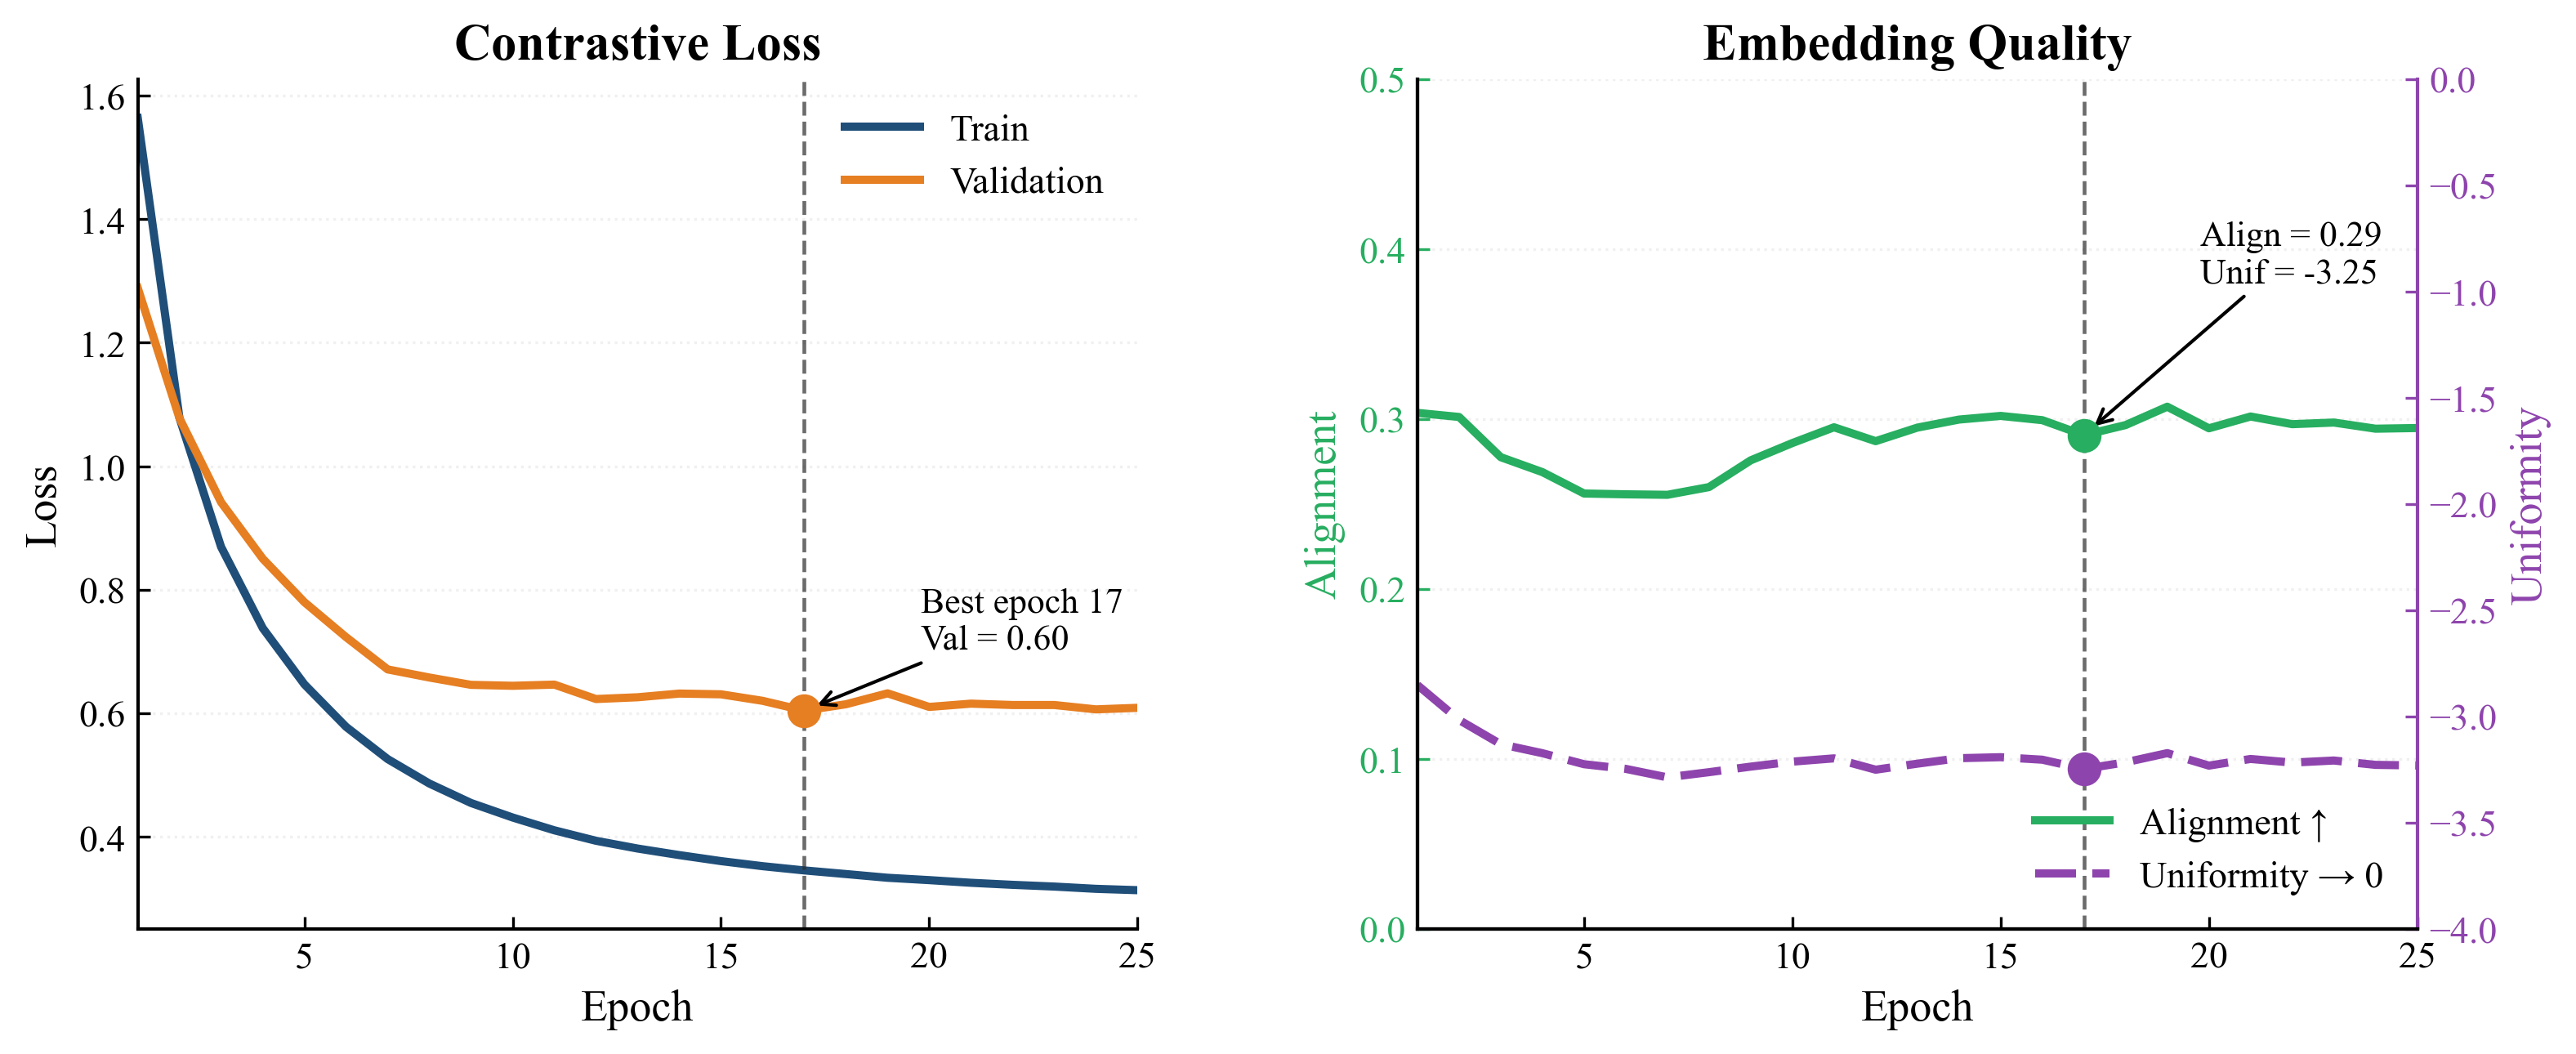

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── Typography & layout (poster optimized) ───────────────────────────────────
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "figure.dpi": 300,
})

# ── Colors (balanced & print-safe) ───────────────────────────────────────────
C_TRAIN = "#1f4e79"
C_VAL   = "#e67e22"
C_ALIGN = "#27ae60"
C_UNIF  = "#8e44ad"
C_BEST  = "#2c2c2c"

# ── Load data ───────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/"
    "atscc_checkpoints_v10_reg/training_history.csv"
)

BEST = 17
best_val   = df.loc[df["epoch"] == BEST, "val_loss"].values[0]
best_align = df.loc[df["epoch"] == BEST, "alignment"].values[0]
best_unif  = df.loc[df["epoch"] == BEST, "uniformity"].values[0]

# ── Figure ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={"wspace": 0.28}
)

# ════════════════════════════════════════════════════════════════════════════
# (a) Contrastive Loss
# ════════════════════════════════════════════════════════════════════════════
ax1.plot(df["epoch"], df["train_loss"],
         color=C_TRAIN, linewidth=2.4, label="Train")

ax1.plot(df["epoch"], df["val_loss"],
         color=C_VAL, linewidth=2.4, label="Validation")

# Best epoch line + point
ax1.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.1, alpha=0.7)
ax1.scatter(BEST, best_val, color=C_VAL, s=80, zorder=5)

# 🔥 Smart annotation (collision-free)
ax1.annotate(
    f"Best epoch {BEST}\nVal = {best_val:.2f}",
    xy=(BEST, best_val),
    xytext=(BEST + 2.8, best_val + 0.10),
    fontsize=10.5,
    ha="left",
    arrowprops=dict(
        arrowstyle="->",
        lw=1,
        shrinkA=0,
        shrinkB=4,
    ),
)

ax1.set_title("Contrastive Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xlim(1, 25)

# Minimal grid (only guidance)
ax1.grid(axis="y", linestyle=":", alpha=0.18)

ax1.legend(loc="upper right")

# ════════════════════════════════════════════════════════════════════════════
# (b) Embedding Quality
# ════════════════════════════════════════════════════════════════════════════
ax3 = ax2.twinx()

l1, = ax2.plot(df["epoch"], df["alignment"],
               color=C_ALIGN, linewidth=2.4,
               label="Alignment ↑")

l2, = ax3.plot(df["epoch"], df["uniformity"],
               color=C_UNIF, linewidth=2.4,
               linestyle=(0, (5, 2)),
               label="Uniformity → 0")

# Best epoch
ax2.axvline(BEST, color=C_BEST, linestyle="--", linewidth=1.1, alpha=0.7)
ax2.scatter(BEST, best_align, color=C_ALIGN, s=80, zorder=5)
ax3.scatter(BEST, best_unif, color=C_UNIF, s=80, zorder=5)

# 🔥 Balanced annotation (no overlap with curve)
ax2.annotate(
    f"Align = {best_align:.2f}\nUnif = {best_unif:.2f}",
    xy=(BEST, best_align),
    xytext=(BEST + 2.8, best_align + 0.09),
    fontsize=10.5,
    ha="left",
    arrowprops=dict(
        arrowstyle="->",
        lw=1,
        shrinkA=0,
        shrinkB=4,
    ),
)

ax2.set_title("Embedding Quality", fontweight="bold")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Alignment", color=C_ALIGN)
ax3.set_ylabel("Uniformity", color=C_UNIF)

# Axis color alignment (important for readability)
ax2.tick_params(axis="y", colors=C_ALIGN)
ax3.tick_params(axis="y", colors=C_UNIF)

# Spine styling (dual-axis clarity)
ax3.spines["right"].set_visible(True)
ax3.spines["right"].set_color(C_UNIF)
ax3.spines["right"].set_linewidth(1.0)

ax2.set_xlim(1, 25)
ax2.set_ylim(0, 0.5)
ax3.set_ylim(-4, 0)

ax2.grid(axis="y", linestyle=":", alpha=0.18)

# Clean legend
ax2.legend(handles=[l1, l2], loc="lower right")

# ── Export (publication ready) ──────────────────────────────────────────────
fig.savefig("atscc_training_poster_FINAL.pdf", bbox_inches="tight")
fig.savefig("atscc_training_poster_FINAL.png", bbox_inches="tight", dpi=300)

plt.show()